In [1]:
import sys
from pathlib import Path

from analysis.aggregations import agg_contribution_score_by_role_relative

REPO_ROOT = Path().resolve().parent.parent
sys.path.insert(0, str(REPO_ROOT))

from analysis import *
from analysis.aggregations import *
from analysis.plots import *

## Jupyter notes

## Multiple runs: Load and transform run

In [2]:
data_dir = REPO_ROOT / "experiment" / "data" / "experimentData"

# Optional: set a timestamp prefix to load only matching runs, e.g. "26-02-26"
# Leave as None to load all runs under experimentData/
PREFIX = None

runs = load_runs_recursive(data_dir, prefix="18-03-26--15_07_18")

# Normalize units: wei → ETH, ratio → %
runs = normalize_runs(runs)
res = merge_runs(runs)

print(f"Loaded {len(runs)} run(s)")

Loaded 1 run(s)


## Plots

## Plot: GRS by user

In [3]:
# # data[['grs', 'user_id', 'round']]
#
# vals = grs_by_user(data)
#
# fig = plot_grs_by_user(vals)


## Plot: Agg. GRS by role

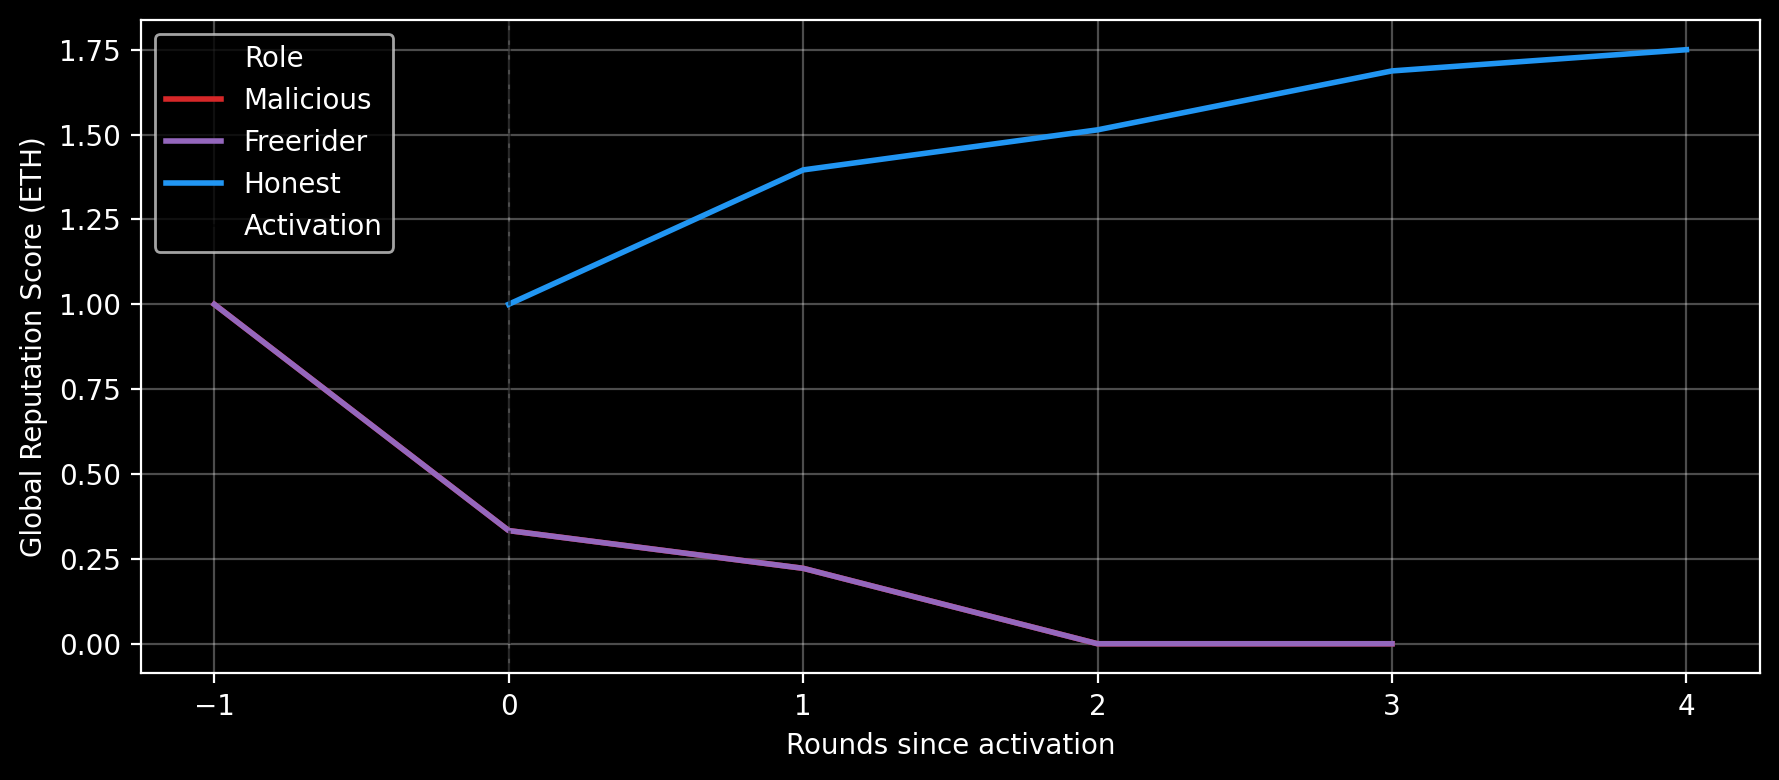

In [4]:
data = res['users']
aggregated = agg_grs_by_role_relative(data, res['metadata'])
fig = plot_grs_by_role_relative(aggregated)

# Per activation round
# Check why mal/fr falls before round 0 (since activation)

## Plot: Model Performance by Global Accuracy for aggregation strategies

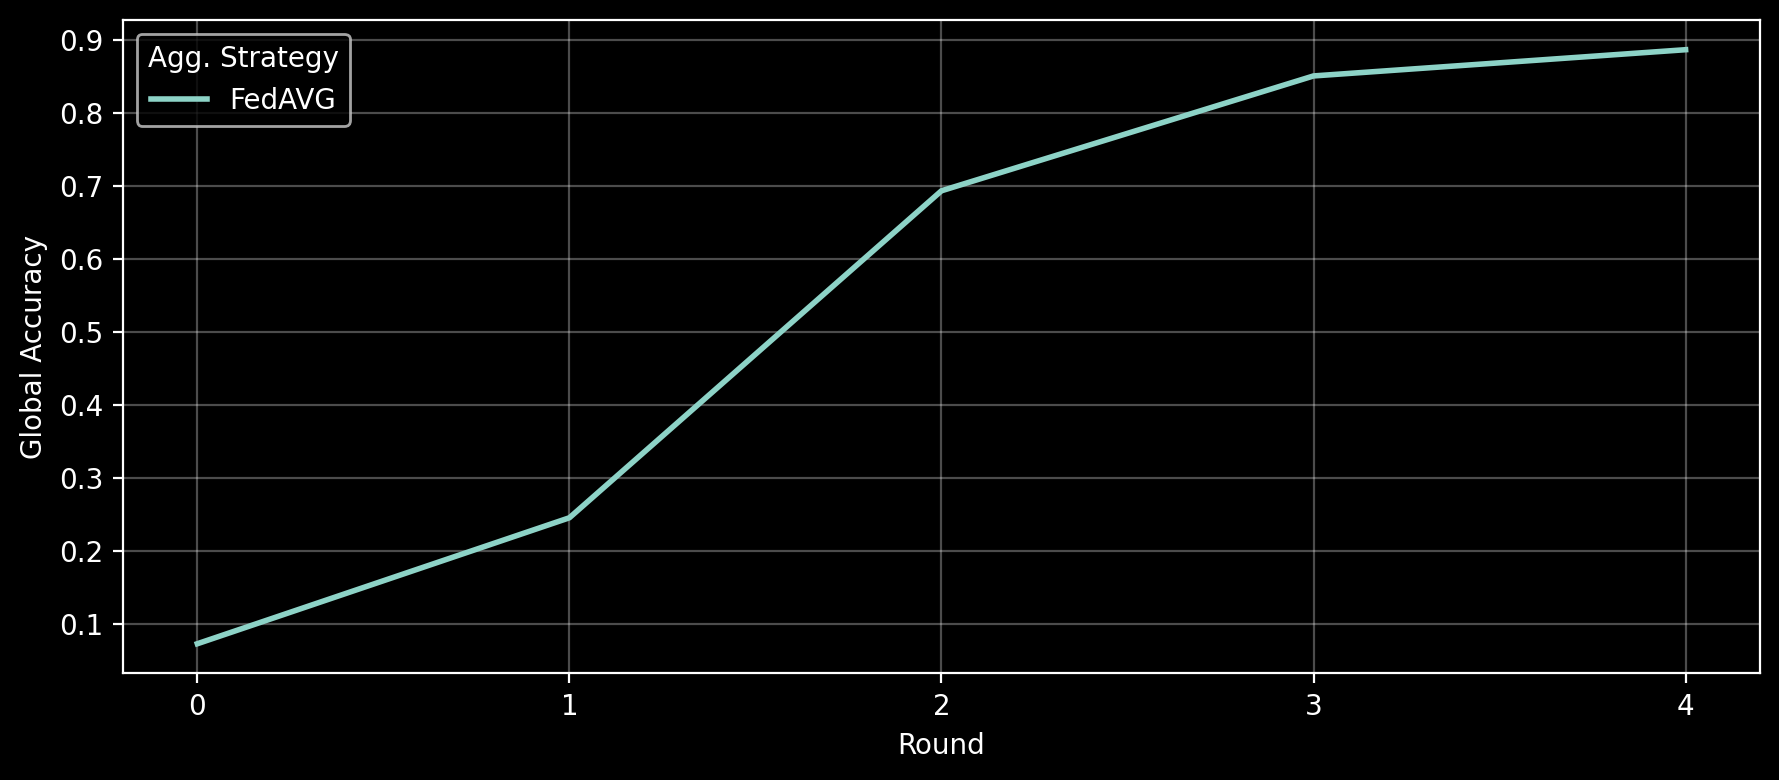

In [5]:
data = res['global']

# It logs self.pytorch_model.accuracy[-1] — so it's the accuracy of the global model evaluated after
# merging all participants' weights each round. That's the true global model performance, distinct from
# individual user accuracies.

# vals = grs_by_user(data)
# data[['round', 'global_accuracy']]
# data[vals['user_id'].isin([4, 5])].sort_values(['user_id', 'round'])

# data

vals = global_acc_by_aggregation_strategy(data, res['metadata'])

fig = plot_global_acc_by_aggregation_strategy(vals)

## Plot: Model Performance by Global Loss for aggregation strategies

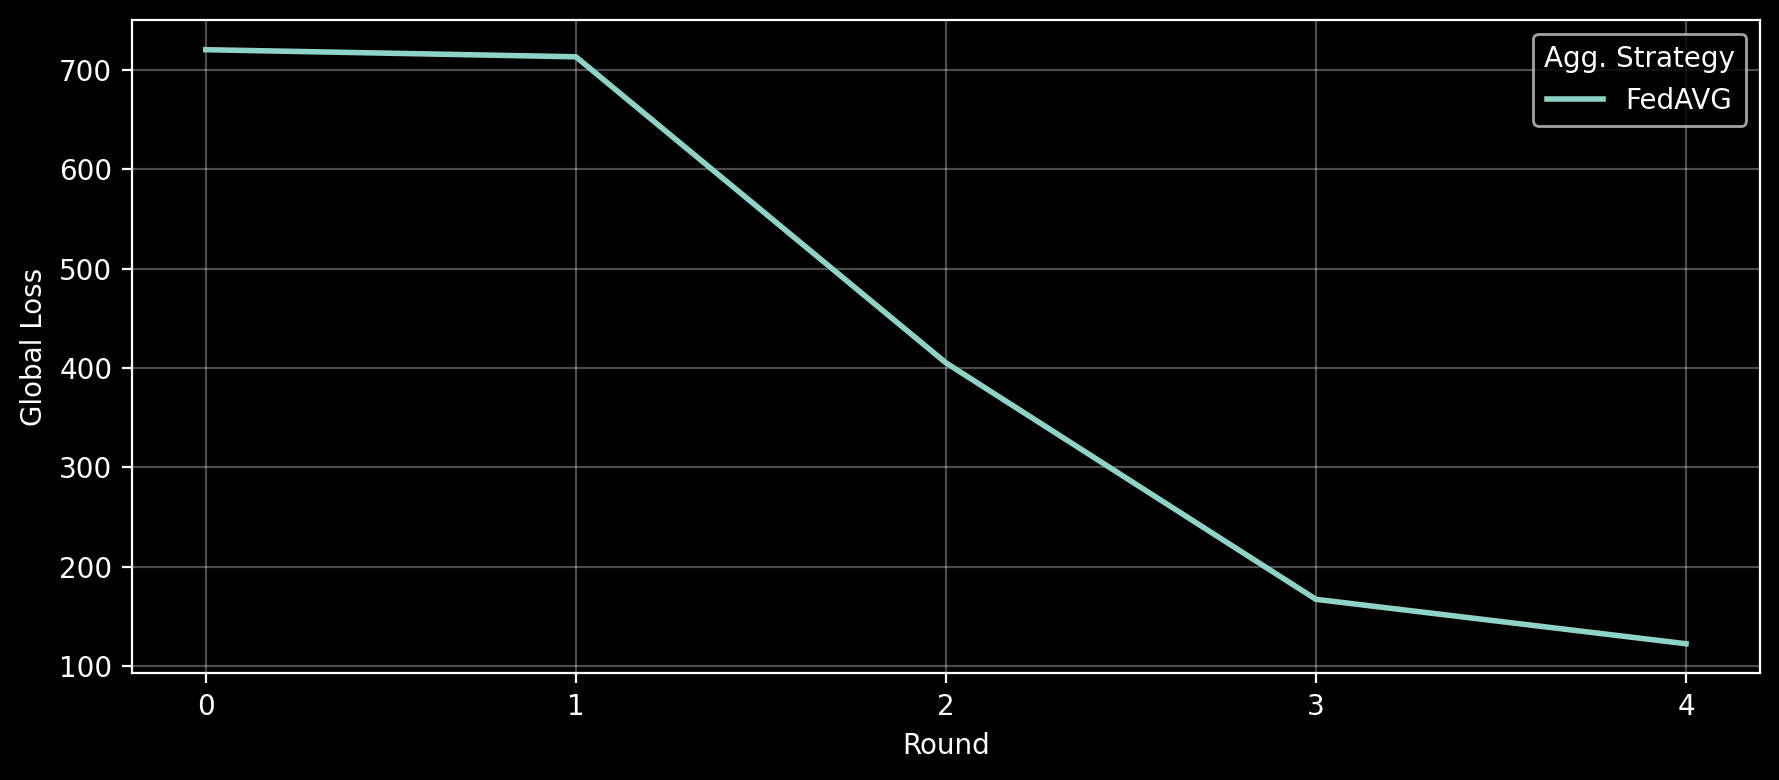

In [6]:
data = res['global']

# ●It logs self.pytorch_model.loss[-1] — so it's the loss of the global model evaluated after
#  merging all participants' weights each round. That's the true global model performance, distinct from
#  individual user accuracies.

# vals = grs_by_user(data)
# data[['round', 'global_loss']]
# data[vals['user_id'].isin([4, 5])].sort_values(['user_id', 'round'])

# data

vals = global_loss_by_aggregation_strategy(data, res['metadata'])
fig = plot_global_loss_by_aggregation_strategy(vals)

### Plot: plot_accuracy_loss_over_rounds

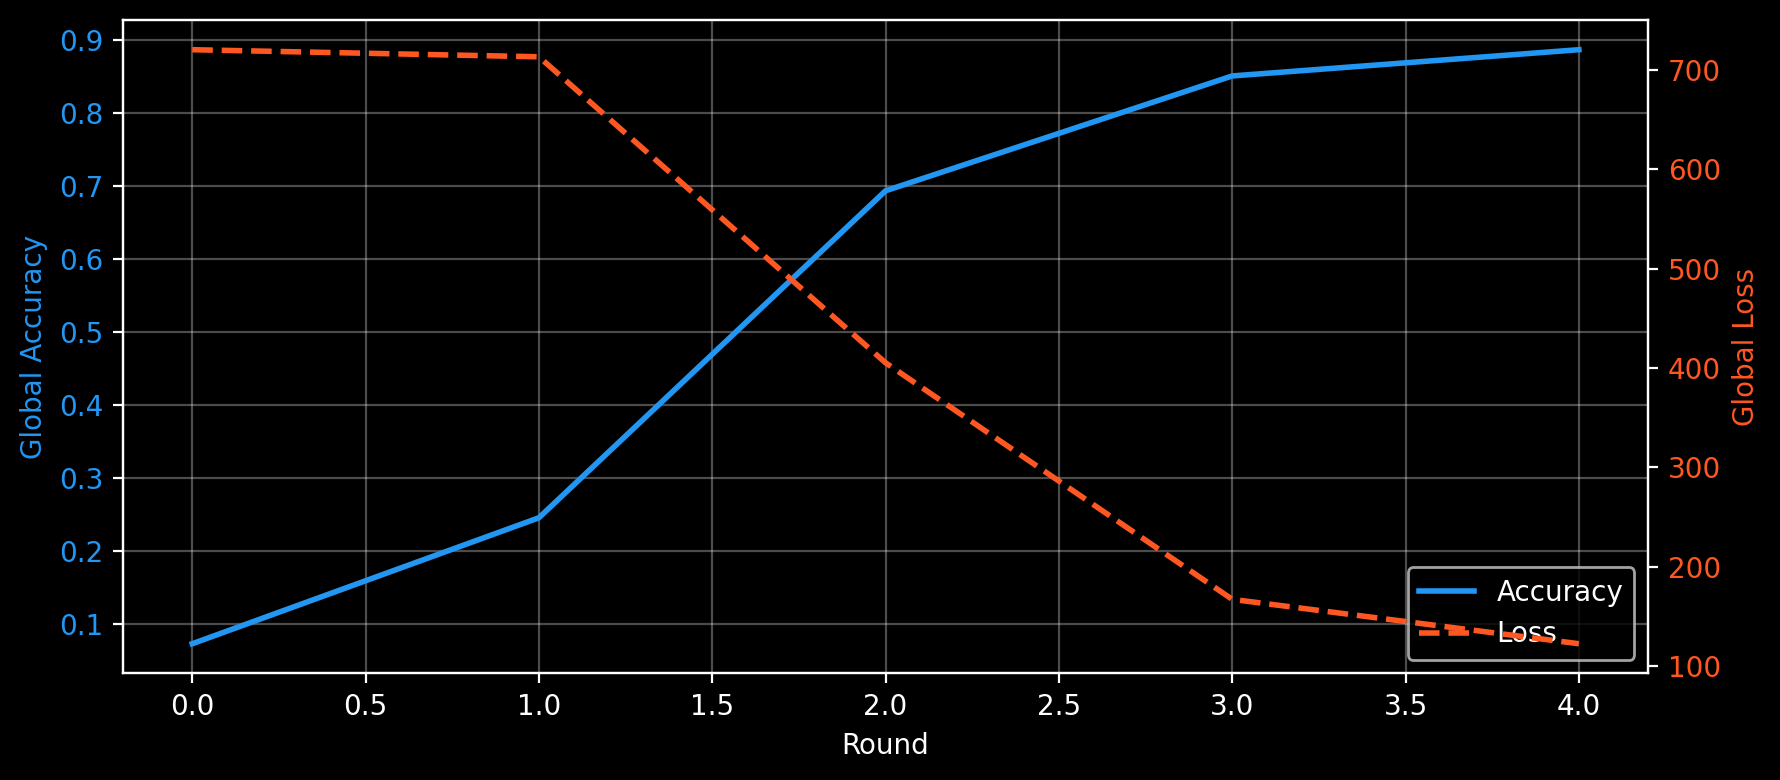

In [7]:
data = res['global']
aggregated = agg_global_accuracy_loss_by_round(data)
fig = plot_accuracy_loss_over_rounds(aggregated) # Assign since it otherwise will plot twice.

### Plot: plot_gas_cost_by_tx_type

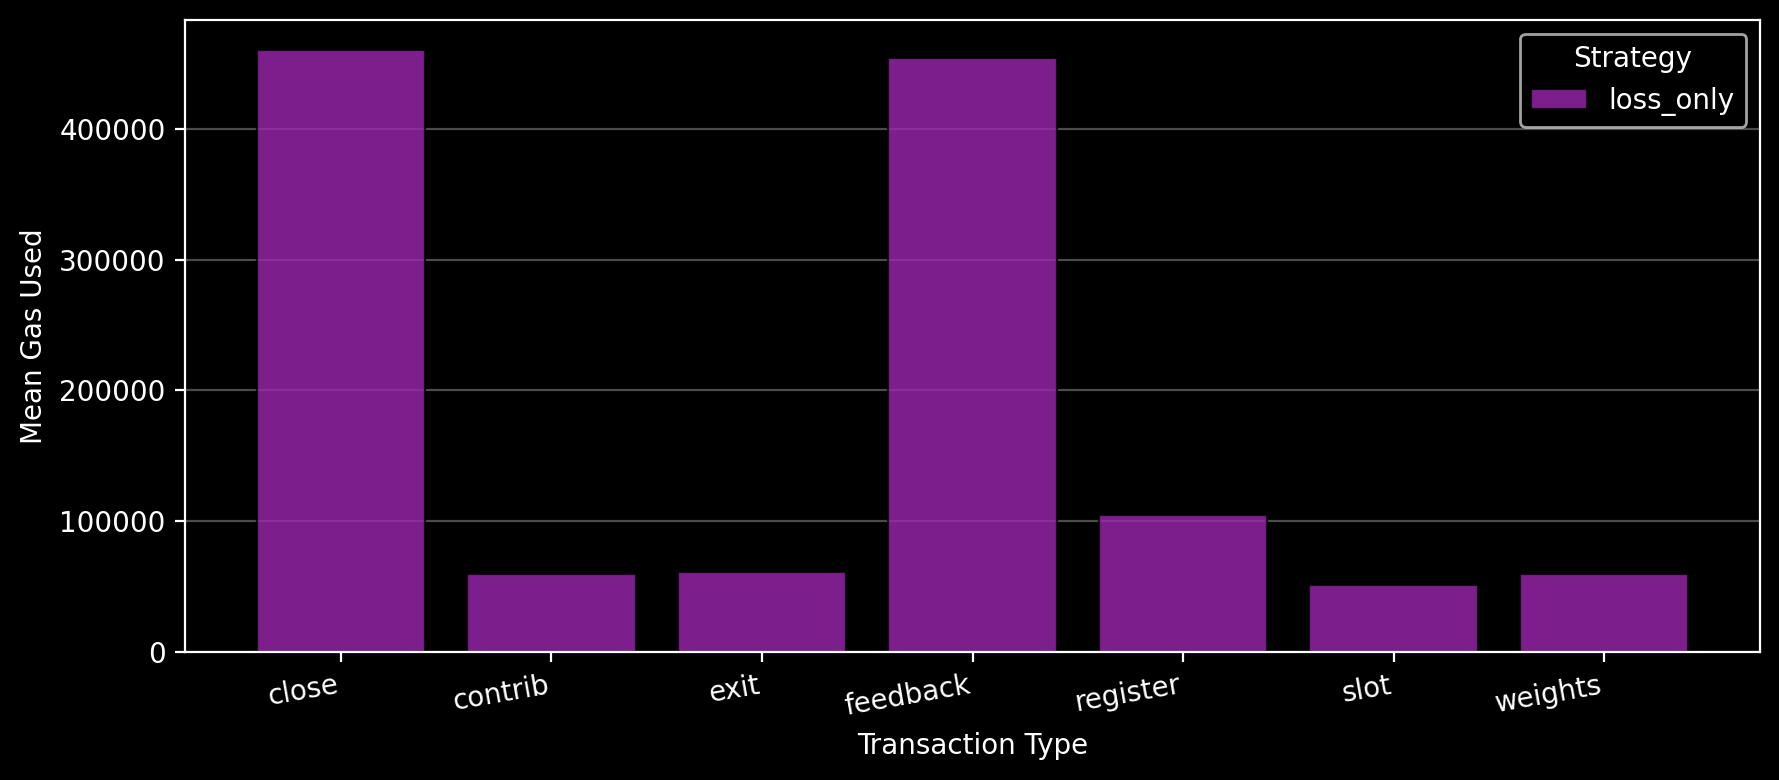

In [8]:
# plot_round_kicked_by_strategy(aggregated)
data = res['receipts']
aggregated = agg_gas_used_by_tx_type(data, res['metadata'])
fig = plot_gas_cost_by_tx_type(aggregated)

## Plot: Contribution score by role (relative)

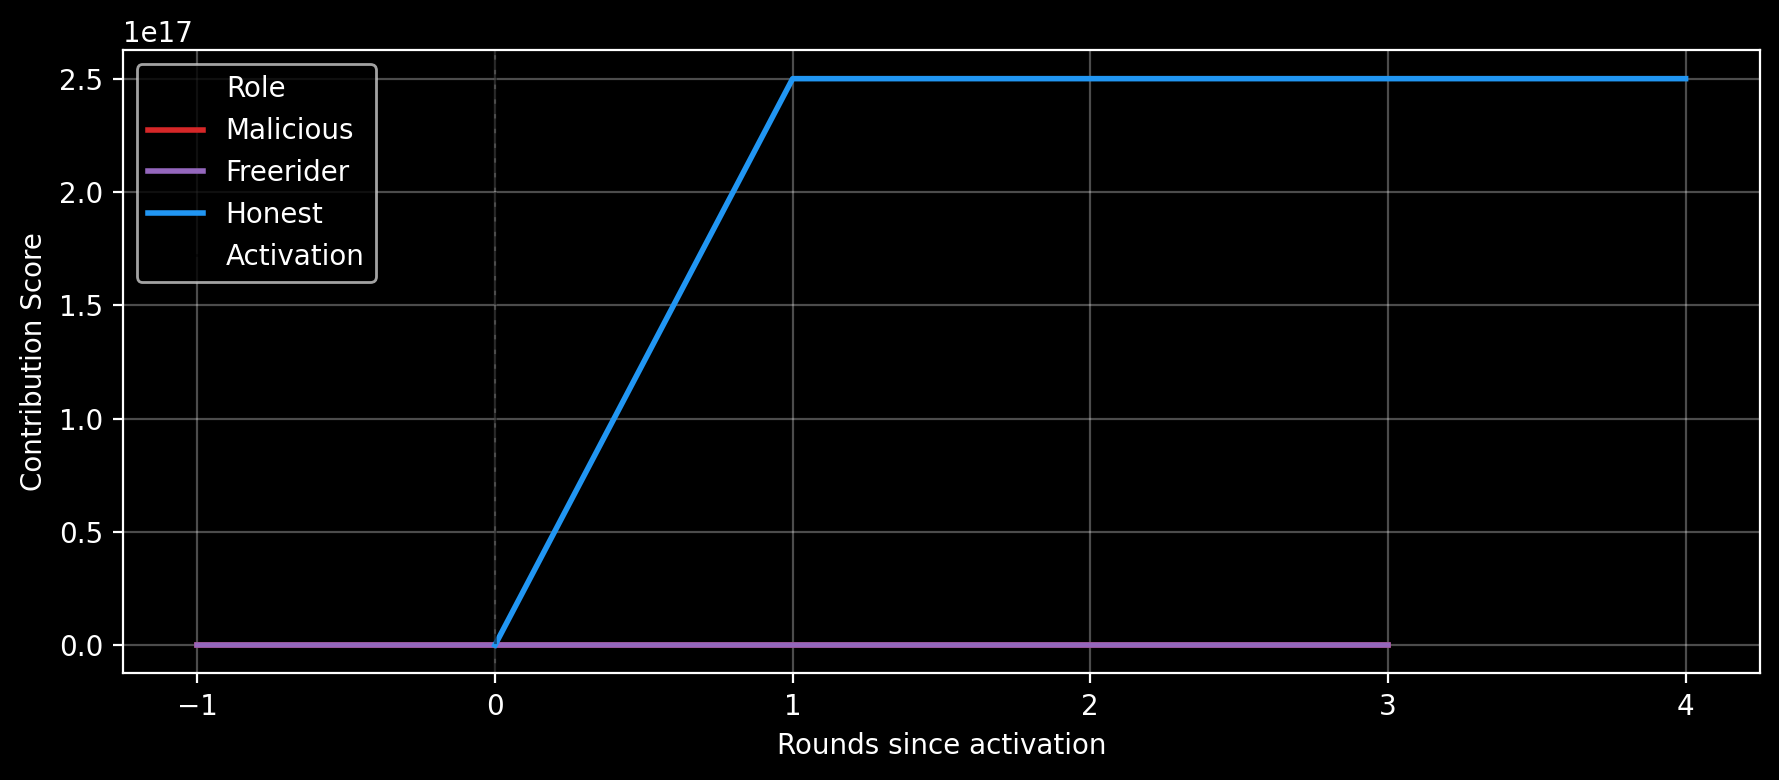

In [9]:
u = res['users']
c = res['contributions']
agg = agg_contribution_score_by_role_relative(u, c, res['metadata'])

fig = plot_contribution_score_by_role_relative(agg)

# Per activation round

## Query: Runtime warnings

In [10]:
# data = res['setup'] does not work

data = res['warnings']


res['votes']